<a href="https://colab.research.google.com/github/SalvadorGR23/Tesis/blob/main/EJEMPLO_BLACK_LITTERMAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**IMPORTACIÓN DE LIBRERÍAS**
En esta sección importamos todas las librerías necesarias para la implementación del código.

In [22]:
!pip install PyPortfolioOpt

import yfinance as yf
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from datetime import date
from pypfopt import EfficientFrontier, plotting

pd.options.display.float_format = '{:,.5f}'.format

#**ENTRADA DE DATOS**
Como primer paso; primero extraeremos los insumos necesarios (datos), para poder llevar a cabo el modelo.

##**PRECIOS HISTÓRICOS DE LOS ACTIVOS**
Como ejemplo; usaremos las acciones de:
* GENOMMA LAB INTERNACIONAL, S.A.B. DE C.V. (LABB.MX)
* GRUPO CARSO, S.A.B. DE C.V. (GCARSOA1.MX)
* WAL - MART DE MEXICO, S.A.B. DE C.V. (WALMEX.MX)
* QUÁLITAS CONTROLADORA, S.A.B. DE C.V. (Q.MX)

Y el periodo de análisi será de 2025-01-01 al 2025-12-31.

Extraemos los precios de cierre de los activos antes mencionado en el periodo descrito.

In [23]:
#Establecer Activos y Periodo de Análisis
tickers = ['LABB.MX', 'GCARSOA1.MX','WALMEX.MX','Q.MX']


fecha_inicio = "2025-01-01"
fecha_fin = "2026-01-01"

#Extracción de Datos
PRECIO_ACTIVOS = yf.download(tickers, start = fecha_inicio, end = fecha_fin)['Close']
PRECIO_ACTIVOS = PRECIO_ACTIVOS.dropna(how = 'all') #Eliminar días sin datos
PRECIO_ACTIVOS.rename_axis(None, axis = 1, inplace = True)
PRECIO_ACTIVOS.reset_index(inplace = True)
PRECIO_ACTIVOS['Date'] = pd.to_datetime(PRECIO_ACTIVOS['Date']).dt.date
PRECIO_ACTIVOS = PRECIO_ACTIVOS[['Date', 'LABB.MX', 'GCARSOA1.MX', 'WALMEX.MX', 'Q.MX']]
PRECIO_ACTIVOS

/tmp/ipykernel_14705/1121054983.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  PRECIO_ACTIVOS = yf.download(tickers, start = fecha_inicio, end = fecha_fin)['Close']
[*********************100%***********************]  4 of 4 completed


,Date,LABB.MX,GCARSOA1.MX,WALMEX.MX,Q.MX
0,2025-01-02,24.70534,114.31873,53.71363,161.48491
1,2025-01-03,25.01295,111.27524,52.92616,157.24884
2,2025-01-06,25.10908,109.97088,53.47058,156.59201
3,2025-01-07,25.72431,111.68037,54.45250,155.16411
4,2025-01-08,25.08024,112.50053,54.31639,156.06844
...,...,...,...,...,...
246,2025-12-24,18.15000,119.86000,57.21000,189.50999
247,2025-12-26,18.07000,119.00000,57.19000,187.99001
248,2025-12-29,17.99000,119.50000,57.02000,191.09000
249,2025-12-30,17.90000,117.21000,56.28000,187.00000


##**PRECIOS HISTÓRICOS DEL MERCADO**
En el contexto de esta tesis; tomamos el IPC como nuestro indpice de datos en el mercado. En la librería de yfinance este se encuentra como ^MXX.

In [24]:
IPC = yf.Ticker('^MXX').history(start = fecha_inicio, end = fecha_fin)['Close']
IPC = IPC.dropna(how = 'all')
IPC = IPC.reset_index()
IPC['Date'] = pd.to_datetime(IPC['Date']).dt.date
IPC

,Date,Close
0,2025-01-02,"49,765.19922"
1,2025-01-03,"48,957.23828"
2,2025-01-06,"49,493.55859"
3,2025-01-07,"50,085.50000"
4,2025-01-08,"49,634.26172"
...,...,...
246,2025-12-24,"65,616.42969"
247,2025-12-26,"65,636.35938"
248,2025-12-29,"65,347.07812"
249,2025-12-30,"64,366.69922"


##**CAPITALIZACIÓN DE LOS ACTIVOS**
La capitalización bursátil es igual al precio de la acción por el número de acciones en circulación. Sin embargo, no es posible obtener de manera histórica el número de acciones en circulación de manera histórica por medio de la libreriá de yfinance.

Por tanto, procedemos a escribir el diccionario con la capitalización bursátil de las acciones de manera manual. Esta información es obtenida a través del sitio de yahoo finanzas; en el apartado de 'Estadísticas' de la acción.
Las cifras se encuentran en Billones de Pesos Mexicanos y corresponde a la fecha final de nuestro periodo de análisis.

In [25]:
capitalizacion_activos = {
    'LABB.MX': 17.44,
    'GCARSOA1.MX': 266.64,
    'WALMEX.MX': 969.27,
    'Q.MX': 73.39
}

#convertir a Dataframe
CAPITALIZACION_ACTIVOS = pd.DataFrame(list(capitalizacion_activos.items()), columns = ['Ticker', 'Capitalizacion'])
CAPITALIZACION_ACTIVOS

,Ticker,Capitalizacion
0,LABB.MX,17.44000
1,GCARSOA1.MX,266.64000
2,WALMEX.MX,969.27000
3,Q.MX,73.39000


##**TASA LIBRE DE RIESGO ($r_f$)**
Para calcular la tasa libre de riesgo ($r_f$), ocupamos la API de Banxico para extraer los datos de la tasa de interés de los CETES a 28 días (en el periodo de análisis definido); para posteriormente calcular esta tasa libre de riesgo.

In [26]:
token_banxico = '6d1357d410effb5edad575bc9bba8f7e231048d7be672adfbfdd88849f8ca5c9'
id_cete = 'SF60633'

url = f'https://www.banxico.org.mx/SieAPIRest/service/v1/series/{id_cete}/datos/{fecha_inicio}/{fecha_fin}'
headers = {'Bmx-Token': token_banxico, 'Accept': 'application/json'}

response = requests.get(url, headers=headers)

CETES_28 = response.json()
CETES_28 = pd.DataFrame(CETES_28['bmx']['series'][0]['datos'])
CETES_28.columns = ['Date', 'Rate']
CETES_28['Date'] = pd.to_datetime(CETES_28['Date'], format='%d/%m/%Y')

CETES_28['Rate'].dropna()
CETES_28['Rate'] = CETES_28['Rate'].astype(float)
CETES_28['Rate'] = CETES_28['Rate']/100
CETES_28

,Date,Rate
0,2025-01-07,0.09880
1,2025-01-14,0.09780
2,2025-01-21,0.09750
3,2025-01-28,0.09870
4,2025-02-04,0.09650
5,2025-02-11,0.09350
6,2025-02-18,0.09370
7,2025-02-25,0.09440
8,2025-03-04,0.09150
9,2025-03-11,0.09140


In [27]:
#La tasa que ofrece CETES en cada subasta es anual, por lo que se convierte a una diaria
CETES_28['Rate'] = CETES_28['Rate']/252

#Calculo tasa libre de riesgo
tasa_libre_riesgo = CETES_28['Rate'].mean()
print('Tasa Libre de Riesgo: ', round(tasa_libre_riesgo, 4))

Tasa Libre de Riesgo:  0.0003


#**CÁLCULO DE PARÁMETROS**

##**RENDIMIENTO ESPERADO DEL PORTAFOLIO DE MERCADO $\mathbb{E}[r_M]$**

In [28]:
rendimiento_esperado_mercado = IPC['Close'].pct_change().mean()
print('Rendimiento Esperado Portafolio de Mercado: ', round(rendimiento_esperado_mercado, 4))

Rendimiento Esperado Portafolio de Mercado:  0.0011


##**VARIANZA DE RENDIMIENTO DE PORTAFOLIO DE MERCADO $\sigma^2_M$**

In [29]:
volatilidad_mercado = IPC['Close'].pct_change().var()
print('Varianza de Rendimiento de Portafolio de Mercado: ', round(volatilidad_mercado, 4))

Varianza de Rendimiento de Portafolio de Mercado:  0.0001


##**MATRIZ DE COVARIANZAS DE LOS ACTIVOS $\Sigma$**

In [30]:
MATRIZ_COVARIANZAS = PRECIO_ACTIVOS.drop(columns=['Date']).pct_change().cov()
MATRIZ_COVARIANZAS

,LABB.MX,GCARSOA1.MX,WALMEX.MX,Q.MX
LABB.MX,0.00048,0.00011,0.00003,0.00008
GCARSOA1.MX,0.00011,0.00057,0.00014,0.00017
WALMEX.MX,0.00003,0.00014,0.00031,0.00007
Q.MX,0.00008,0.00017,0.00007,0.00054


##**VECTOR DE PONDERACIONES DE CAPITALIZACIÓN $W_{mkt}$**

In [31]:
ponderaciones = CAPITALIZACION_ACTIVOS['Capitalizacion'] / CAPITALIZACION_ACTIVOS['Capitalizacion'].sum()

PONDERACIONES_CAPITALIZACION = pd.DataFrame({
  'Ticker': CAPITALIZACION_ACTIVOS['Ticker'],
  'Ponderacion': ponderaciones
})

PONDERACIONES_CAPITALIZACION

,Ticker,Ponderacion
0,LABB.MX,0.01315
1,GCARSOA1.MX,0.20097
2,WALMEX.MX,0.73057
3,Q.MX,0.05532


#**VECTOR DE RENDIMIENTOS DE EQUILIBRIO $\Pi$**

##**AVERSIÓN AL RIESGO $\lambda$**

In [32]:
aversion_riesgo = (rendimiento_esperado_mercado - tasa_libre_riesgo)/volatilidad_mercado
print('Aversion al Riesgo: ', round(aversion_riesgo, 4))

Aversion al Riesgo:  7.7805


##**VECTOR DE RENDIMIENTOS DE EQUILIBRIO $\Pi$**

$\Pi = \lambda\Sigma w_{mkt}$

In [33]:
w_mkt = PONDERACIONES_CAPITALIZACION.set_index('Ticker')['Ponderacion']

rendimientos_equilibrio = aversion_riesgo * MATRIZ_COVARIANZAS.dot(w_mkt)

RENDIMIENTOS_EQUILIBRIO = pd.DataFrame(rendimientos_equilibrio, columns=['Rendimiento Equilibrio'])
RENDIMIENTOS_EQUILIBRIO.reset_index(inplace=True)

RENDIMIENTOS_EQUILIBRIO

,index,Rendimiento Equilibrio
0,LABB.MX,0.00044
1,GCARSOA1.MX,0.00175
2,WALMEX.MX,0.00201
3,Q.MX,0.00091


#**PERSPECTIVAS DEL INVERSIONISTA**
* La acción de GENOMMA LAB INTERNACIONAL, S.A.B. DE C.V. (LABB.MX) tendrá un rendimiento del 10%.
* La acción de WAL - MART DE MEXICO, S.A.B. DE C.V. (WALMEX.MX) superará los rendimientos de la acción de QUÁLITAS CONTROLADORA, S.A.B. DE C.V. (Q.MX) en un 20%.

##**MATRIZ $P$**

In [34]:
P = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, -1]
])

##**MATRIZ $Q$**

In [35]:
Q = np.array([
    [0.10],
    [0.20]
])

##**MATRIZ DE INCERTIDUMBRE DE LAS PERSPECTIVAS $\Omega$**

$\Omega = diag(P(\tau \Sigma)P^T)$

donde $\tau = 0.05$

In [36]:
tau = 0.05
P_T = P.T
P_SIGMA_P_T = np.dot(P, np.dot(MATRIZ_COVARIANZAS, P_T))
diagonal_omega = np.diag(P_SIGMA_P_T)

omega = np.diag(diagonal_omega * tau)
views = ['LABB.MX (10% Rendimiento)', 'WALMEX.MX > Q.MX (20% Rendimiento)']
OMEGA = pd.DataFrame(omega, index = views, columns=views)

OMEGA

,LABB.MX (10% Rendimiento),WALMEX.MX > Q.MX (20% Rendimiento)
LABB.MX (10% Rendimiento),0.00002,0.00000
WALMEX.MX > Q.MX (20% Rendimiento),0.00000,0.00004


#**RENDIMIENTOS AJUSTADO $\mathbb{E}[R_{BL}]$**

$\mathbb{E}[R_{BL}] = {[{(\tau\Sigma)}^{-1} + P^{T}\Omega^{-1}P]}^{-1}[{(\tau\Sigma)}^{-1}\Pi + P^{T}\Omega^{-1}Q]$

donde;
* $A = {[{(\tau\Sigma)}^{-1} + P^{T}\Omega^{-1}P]}^{-1}$
* $B = [{(\tau\Sigma)}^{-1}\Pi + P^{T}\Omega^{-1}Q]$

In [37]:
sigma = MATRIZ_COVARIANZAS.to_numpy()
pi = RENDIMIENTOS_EQUILIBRIO['Rendimiento Equilibrio'].to_numpy().reshape(-1, 1)
omega = OMEGA.to_numpy()

tau_sigma_inversa = np.linalg.inv(tau * sigma)
omega_inversa = np.linalg.inv(omega)

#A
A = tau_sigma_inversa + P_T @ omega_inversa @ P
A = np.linalg.inv(A)

#B
B_1 = tau_sigma_inversa @ pi
B_2 = P_T @ omega_inversa @ Q
B = B_1 + B_2


rendimientos_ajustados = A @ B

tickers_list = MATRIZ_COVARIANZAS.index.tolist()
RENDIMIENTOS_AJUSTADOS = pd.DataFrame(rendimientos_ajustados, index = tickers_list, columns = ['Rendimiento Ajustado'])
RENDIMIENTOS_AJUSTADOS.reset_index(inplace = True)
RENDIMIENTOS_AJUSTADOS.columns = ['Ticker', 'Rendimiento Ajustado']
RENDIMIENTOS_AJUSTADOS

,Ticker,Rendimiento Ajustado
0,LABB.MX,0.04659
1,GCARSOA1.MX,0.01001
2,WALMEX.MX,0.03997
3,Q.MX,-0.05780


#**OPTIMIZACIÓN MARKOWITZ**

In [38]:
n_portfolios = 1_000_000
rendimientos = []
volatilidades = []
ratios_sharpe = []
dataframes_asignaciones = []

for _ in range(n_portfolios):
    pesos = np.random.random(len(tickers))
    pesos /= np.sum(pesos)
    ASIGNACIONES = pd.DataFrame(pesos, index = tickers, columns = ['Asignacion'])

    rendimiento = np.dot(pesos, RENDIMIENTOS_AJUSTADOS['Rendimiento Ajustado'].to_numpy())
    volatilidad = np.sqrt(np.dot(pesos.T, np.dot(MATRIZ_COVARIANZAS, pesos)))

    rendimientos.append(rendimiento)
    volatilidades.append(volatilidad)
    ratios_sharpe.append((rendimiento - tasa_libre_riesgo) / volatilidad)
    dataframes_asignaciones.append(ASIGNACIONES)

ASIGNACION = dataframes_asignaciones[np.argmax(ratios_sharpe)]
ASIGNACION = ASIGNACION.reset_index()
ASIGNACION.columns = ['Ticker', 'Asignacion']
ASIGNACION

,Ticker,Asignacion
0,LABB.MX,0.41623
1,GCARSOA1.MX,0.00031
2,WALMEX.MX,0.58285
3,Q.MX,0.00061


/tmp/ipykernel_14705/1243423296.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


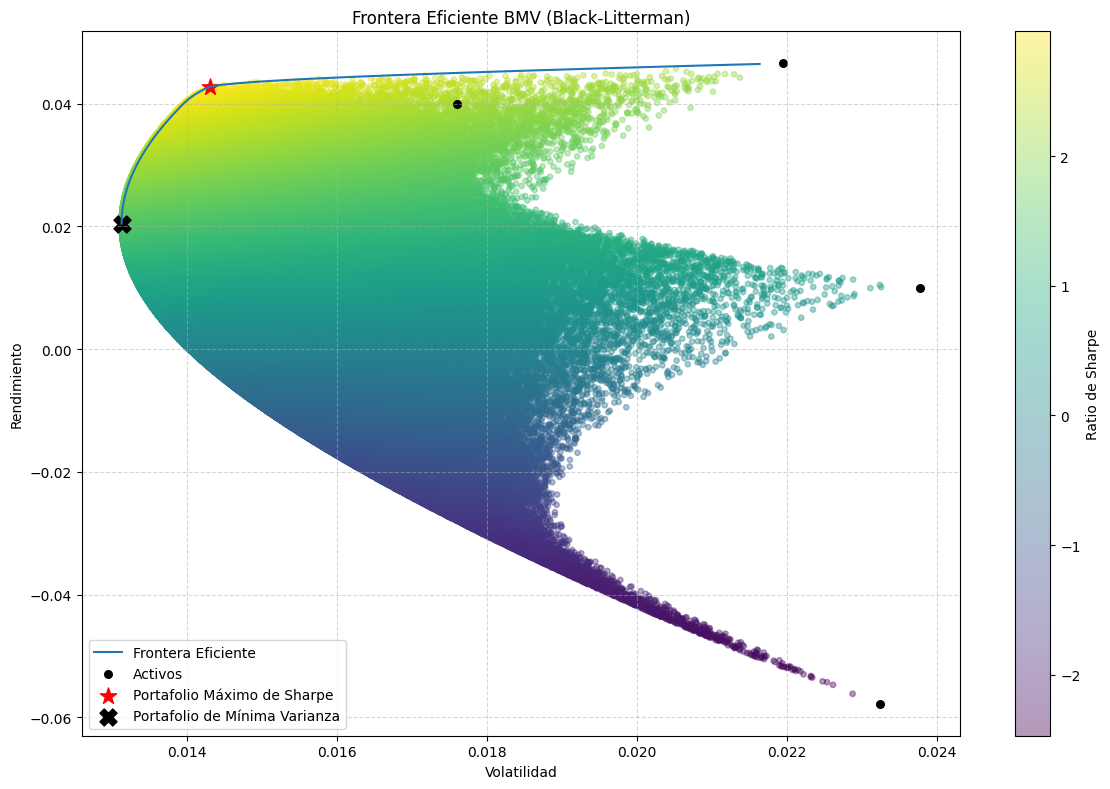

In [40]:
# 5. Visualización
fig, ax = plt.subplots(figsize = (12, 8))

# A. Dibujar la nube de carteras aleatorias
scatter = ax.scatter(volatilidades, rendimientos, c = ratios_sharpe, cmap = 'viridis', alpha = 0.4, marker = 'o', s = 15)
plt.colorbar(scatter, label = 'Ratio de Sharpe')

# B. Calcular y dibujar la Frontera Eficiente (línea)
ef = EfficientFrontier(RENDIMIENTOS_AJUSTADOS['Rendimiento Ajustado'].to_numpy(), MATRIZ_COVARIANZAS)
plotting.plot_efficient_frontier(ef, ax = ax, show_assets = True)

# C. Marcar puntos clave
# Cartera de Máximo Sharpe
ef_max = EfficientFrontier(RENDIMIENTOS_AJUSTADOS['Rendimiento Ajustado'].to_numpy(), MATRIZ_COVARIANZAS)
ef_max.max_sharpe()
ret_max, std_max, _ = ef_max.portfolio_performance()
ax.scatter(std_max, ret_max, marker = "*", s = 150, c = "red", label = "Portafolio Máximo de Sharpe")

# Cartera de Mínima Varianza
ef_min = EfficientFrontier(RENDIMIENTOS_AJUSTADOS['Rendimiento Ajustado'].to_numpy(), MATRIZ_COVARIANZAS)
ef_min.min_volatility()
ret_min, std_min, _ = ef_min.portfolio_performance()
ax.scatter(std_min, ret_min, marker = "X", s = 150, c = "black", label = "Portafolio de Mínima Varianza")

# Formato final
ax.set_title(f"Frontera Eficiente BMV (Black-Litterman)")
ax.set_xlabel("Volatilidad")
ax.set_ylabel("Rendimiento")

# Get current handles and labels from the plot to modify the legend
handles, labels = ax.get_legend_handles_labels()

# Modify labels
new_labels = []
for label in labels:
    if label == 'Efficient frontier':
        new_labels.append('Frontera Eficiente')
    elif label == 'assets':
        new_labels.append('Activos')
    else:
        new_labels.append(label)

ax.legend(handles, new_labels)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()